In [1]:
%cd /home/ytee/test/trade_bot/
import os
print(os.getcwd())
from src.pattern.ccy_strength import CCY_STR, CCY_STR_DEBUG, SMOOTHING_METHOD
from src.pattern.helper import HELPER
c = CCY_STR(['AUD', 'JPY', 'USD', 'GBP', 'CAD', 'CHF', 'EUR', 'XAU', 'XAG', 'OIL', 'GAS'])
import pandas as pd
xx = {}



/home/ytee/test/trade_bot
/home/ytee/test/trade_bot


/home/ytee/test/trade_bot/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [10]:
xx =c.smoothing_method(300).dropna()

xx.columns, xx.index
rank_df = xx.rank(axis=1, method='min', ascending=False)
rank_df

,AUD,JPY,USD,GBP,CAD,CHF,EUR,XAU,XAG,OIL,GAS
2001-06-18,11.0,9.0,2.0,8.0,5.0,6.0,7.0,4.0,10.0,3.0,1.0
2001-06-19,11.0,10.0,3.0,8.0,5.0,6.0,7.0,4.0,9.0,2.0,1.0
2001-06-20,11.0,10.0,3.0,8.0,5.0,6.0,7.0,4.0,9.0,2.0,1.0
2001-06-21,11.0,10.0,3.0,8.0,5.0,6.0,7.0,4.0,9.0,2.0,1.0
2001-06-22,10.0,11.0,3.0,8.0,5.0,6.0,7.0,4.0,9.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-17,9.0,8.0,5.0,4.0,10.0,7.0,6.0,2.0,3.0,11.0,1.0
2025-03-18,9.0,8.0,5.0,4.0,10.0,7.0,6.0,2.0,3.0,11.0,1.0
2025-03-19,9.0,8.0,5.0,4.0,10.0,7.0,6.0,2.0,3.0,11.0,1.0
2025-03-20,11.0,9.0,5.0,4.0,10.0,8.0,6.0,2.0,3.0,7.0,1.0


In [2]:
for method in SMOOTHING_METHOD:
    for i in range(10, 700, 10):
        c.mt5_export(window=i, method=method)

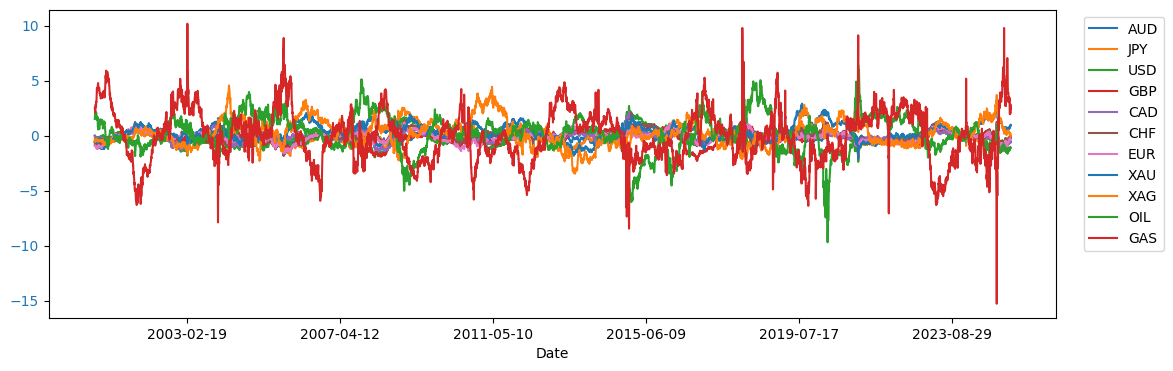

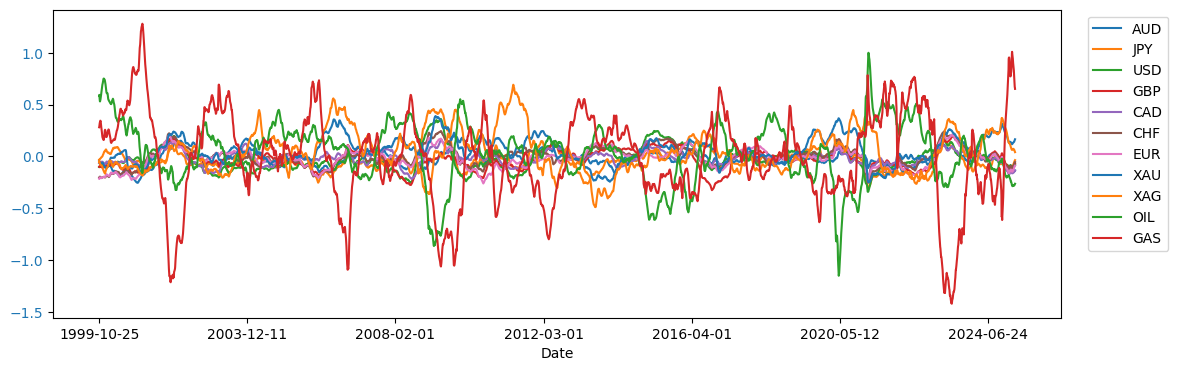

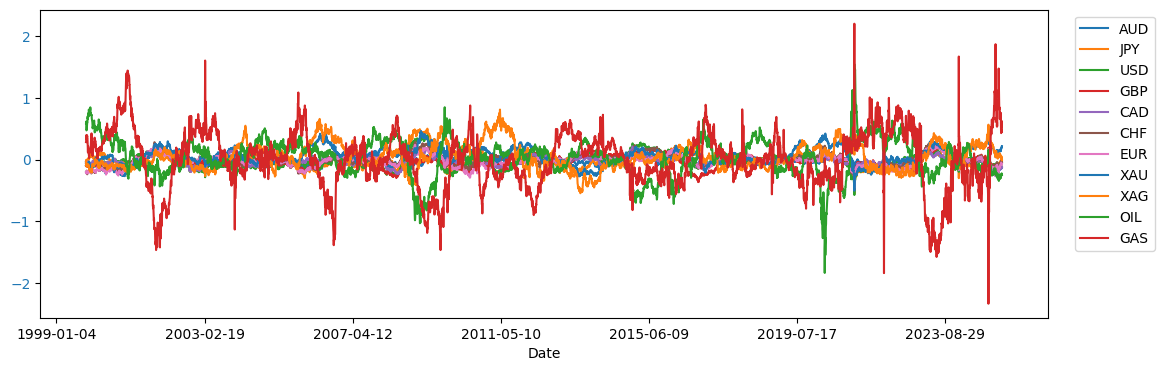

In [2]:
HELPER.plot_chart(c.rolling_cross_csi_zscore(window=200))
HELPER.plot_chart(c.kalman_csi(window=200))
HELPER.plot_chart(c.compute_csi(window=200))

In [3]:
c.get_pending_trades_all(400)

,year,ccy,entry_idx,entry_price,spread,ccy1_rank,ccy2_rank,method,direction
0,2025,AUDGAS,2025-01-17,0.062982,-5.334718,3,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1
1,2025,JPYGAS,2025-01-17,0.000649,-5.570640,1,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1
2,2025,USDGAS,2025-01-17,0.101420,-5.195377,7,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1
3,2025,GBPGAS,2025-01-17,0.123540,-5.254153,5,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1
4,2025,CADGAS,2025-01-17,0.070333,-5.395019,2,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1
5,2025,CHFGAS,2025-01-17,0.110866,-5.202361,6,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1
6,2025,EURGAS,2025-01-17,0.104331,-5.313136,4,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1
7,2025,OILGAS,2025-01-17,7.967546,-4.715870,8,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1


In [4]:
c.get_pending_trades_all(300)

,year,ccy,entry_idx,entry_price,spread,ccy1_rank,ccy2_rank,method,direction
0,2025,AUDXAU,2025-03-05,0.000216,-2.003803,3,10,SMOOTHING_METHOD.ROLLING_ZSCORE,1
1,2025,AUDGAS,2025-01-17,0.062982,-5.412032,6,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1
2,2025,JPYXAU,2025-03-14,0.000002,-2.042468,4,10,SMOOTHING_METHOD.ROLLING_ZSCORE,1
3,2025,JPYGAS,2025-01-17,0.000649,-5.505735,3,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1
4,2025,USDGAS,2025-01-17,0.101420,-5.326937,7,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1
5,2025,GBPGAS,2025-01-17,0.123540,-5.312426,8,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1
6,2025,CADXAU,2025-03-04,0.000237,-2.022686,1,10,SMOOTHING_METHOD.ROLLING_ZSCORE,1
7,2025,CADGAS,2025-01-17,0.070333,-5.524830,2,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1
8,2025,CHFXAU,2025-03-19,0.000375,-2.107679,5,10,SMOOTHING_METHOD.ROLLING_ZSCORE,1
9,2025,CHFGAS,2025-01-17,0.110866,-5.420636,5,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1


In [5]:
c.get_scaled_params(train_ratio=0.3)

,ccy,window,train_ratio,mean,std
0,AUDJPY,10,0.3,0.024480,0.672311
1,AUDUSD,10,0.3,0.022248,0.605230
2,AUDGBP,10,0.3,0.018945,0.542696
3,AUDCAD,10,0.3,-0.015203,0.503064
4,AUDCHF,10,0.3,0.028994,0.604404
...,...,...,...,...,...
2470,XAUOIL,450,0.3,-0.686099,1.390033
2471,XAUGAS,450,0.3,-0.545205,2.301808
2472,XAGOIL,450,0.3,-0.455517,1.131115
2473,XAGGAS,450,0.3,-0.314624,2.587665


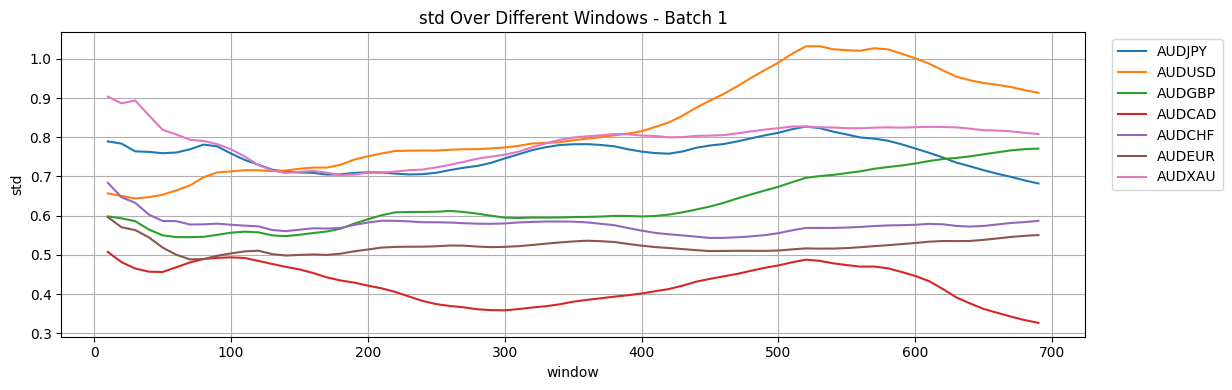

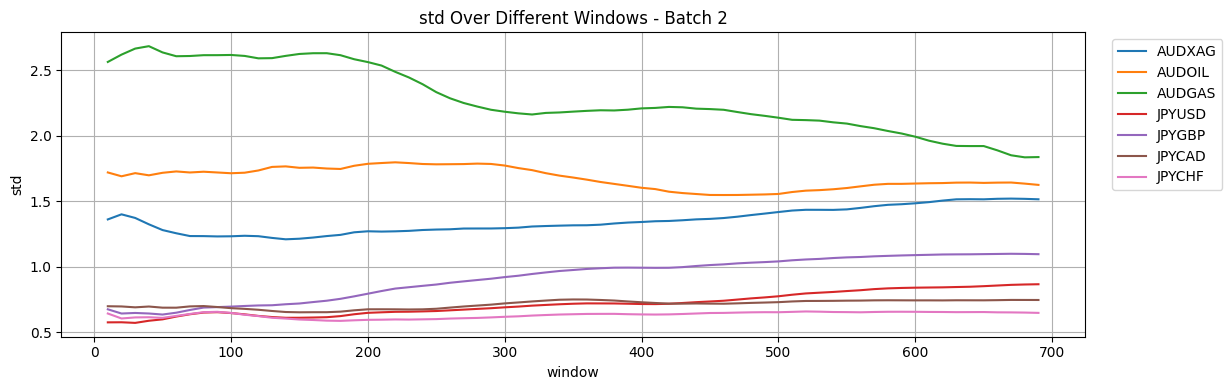

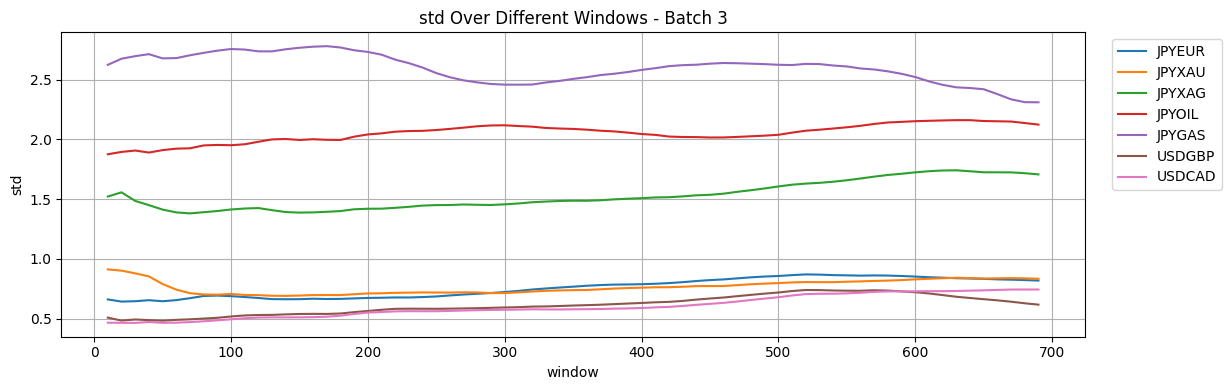

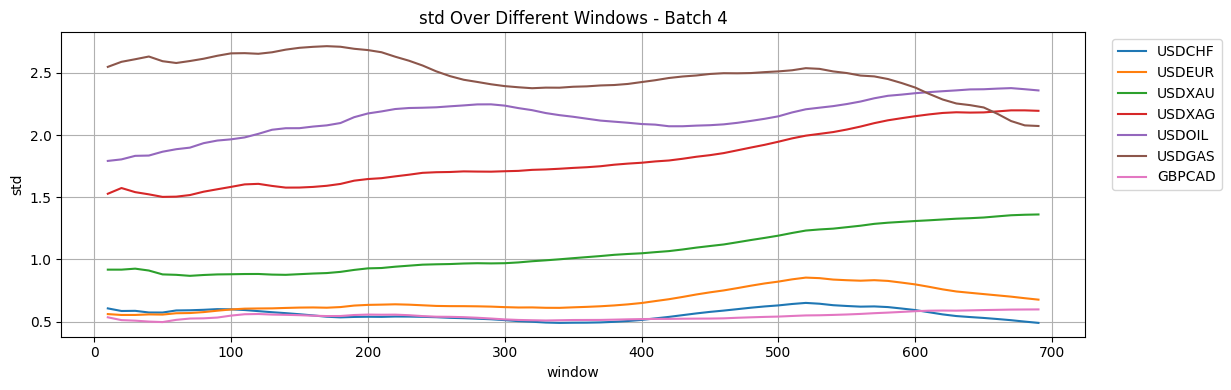

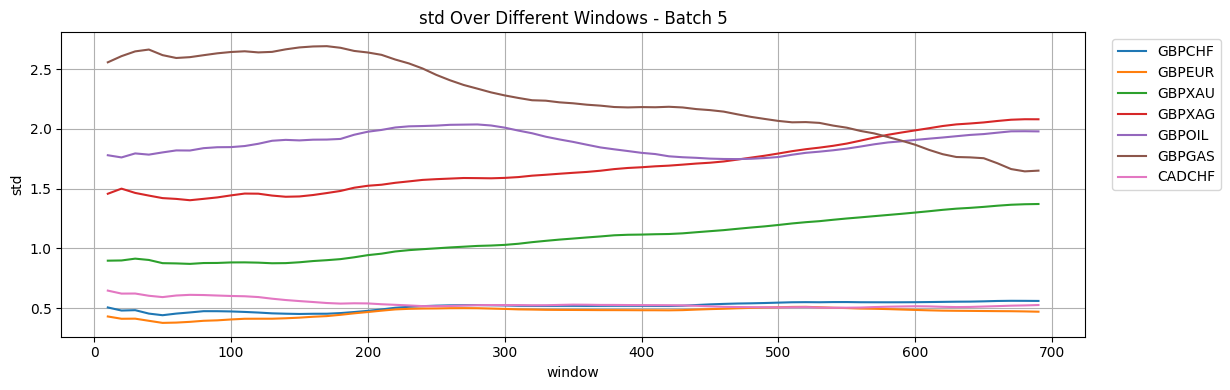

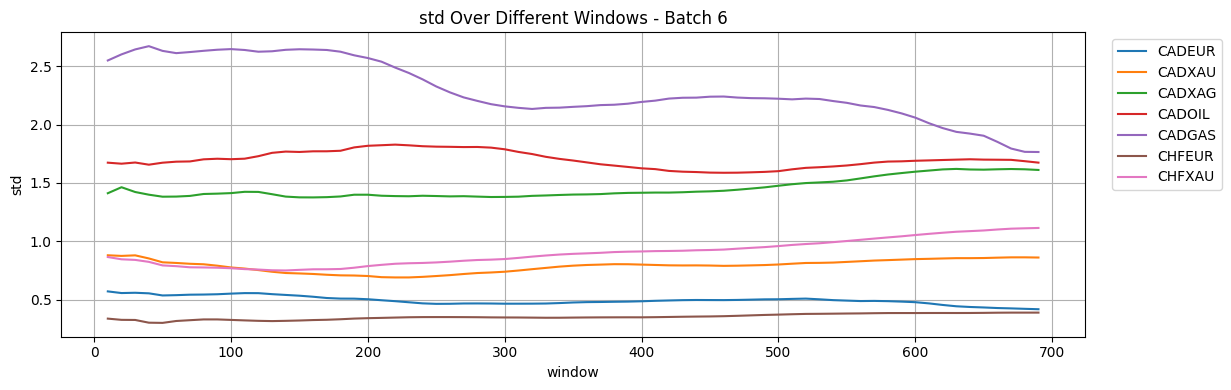

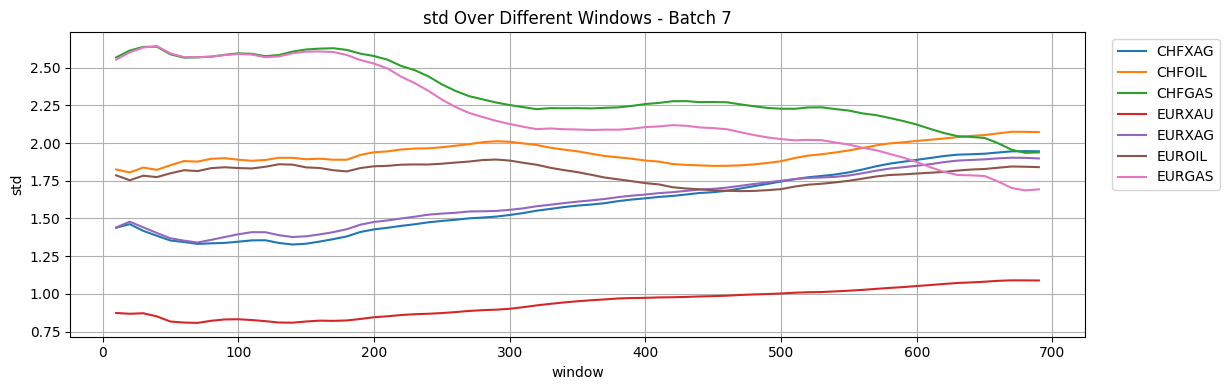

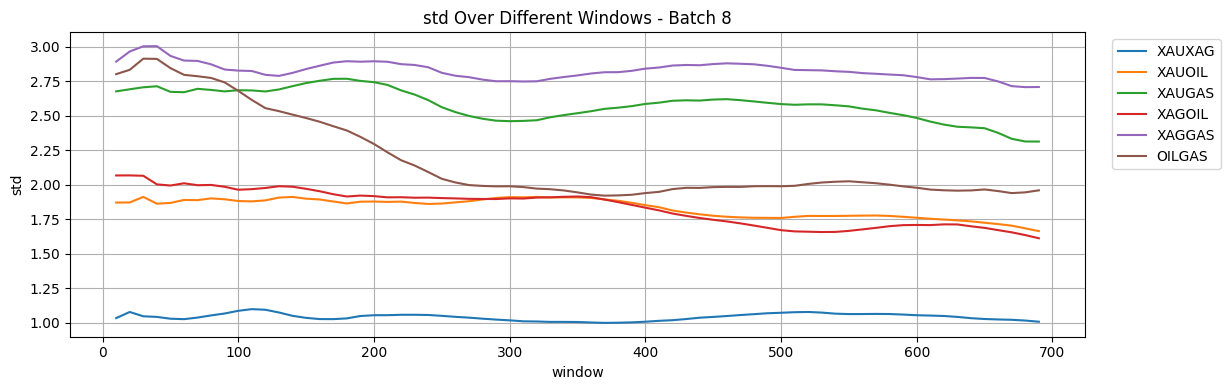

In [6]:

df = c.get_scaled_params(train_ratio=0.7)

HELPER.plot_pivot(df, 'window',  'std', 'ccy', batches=len(df.ccy.unique())//7+1)

In [7]:
c.get_scaled_params(train_ratio=1)

,ccy,window,train_ratio,mean,std
0,AUDJPY,10,1,0.021909,0.728768
1,AUDUSD,10,1,-0.001276,0.611202
2,AUDGBP,10,1,0.010327,0.560898
3,AUDCAD,10,1,-0.011208,0.465183
4,AUDCHF,10,1,-0.008836,0.623762
...,...,...,...,...,...
3790,XAUOIL,690,1,0.480124,1.952004
3791,XAUGAS,690,1,1.102381,2.472660
3792,XAGOIL,690,1,0.312018,1.905101
3793,XAGGAS,690,1,0.934275,2.637266


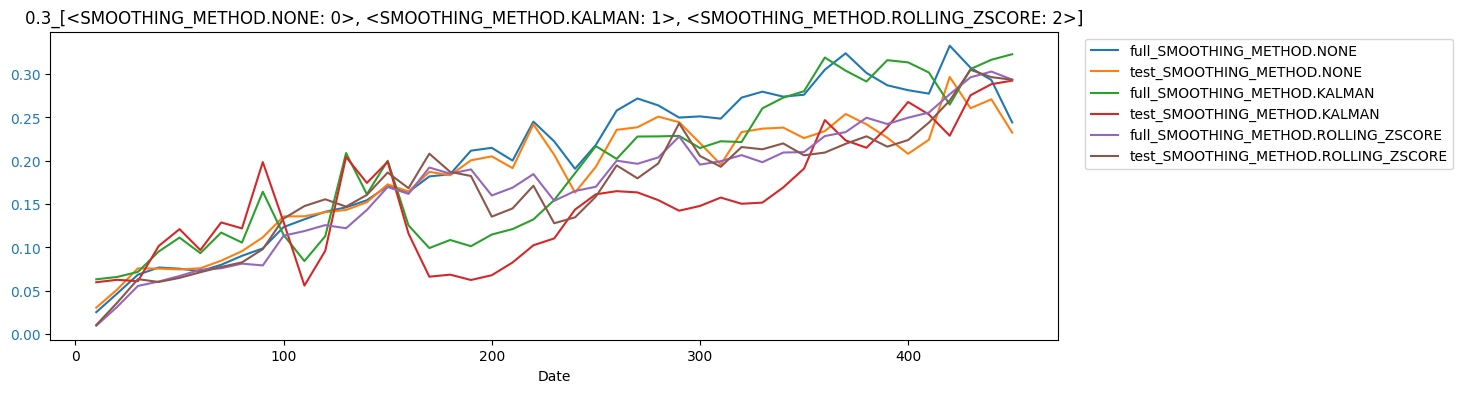

,full_SMOOTHING_METHOD.NONE,test_SMOOTHING_METHOD.NONE,full_SMOOTHING_METHOD.KALMAN,test_SMOOTHING_METHOD.KALMAN,full_SMOOTHING_METHOD.ROLLING_ZSCORE,test_SMOOTHING_METHOD.ROLLING_ZSCORE
10,0.025360,0.030545,0.063289,0.059881,0.009715,0.010570
20,0.046788,0.051380,0.066000,0.062715,0.031409,0.036138
30,0.068595,0.075922,0.071798,0.061125,0.055618,0.063447
40,0.076892,0.075655,0.095340,0.101693,0.060718,0.060211
50,0.075508,0.074644,0.111423,0.121177,0.067060,0.064894
60,0.072698,0.076026,0.093448,0.097024,0.074331,0.071450
70,0.080018,0.084732,0.117215,0.128913,0.075988,0.077527
80,0.090370,0.095744,0.105658,0.122015,0.081367,0.082811
90,0.098938,0.111667,0.164305,0.198567,0.079298,0.098080
100,0.123577,0.135847,0.114463,0.129312,0.113615,0.133339


In [8]:
c.compare_pnl(0.3)

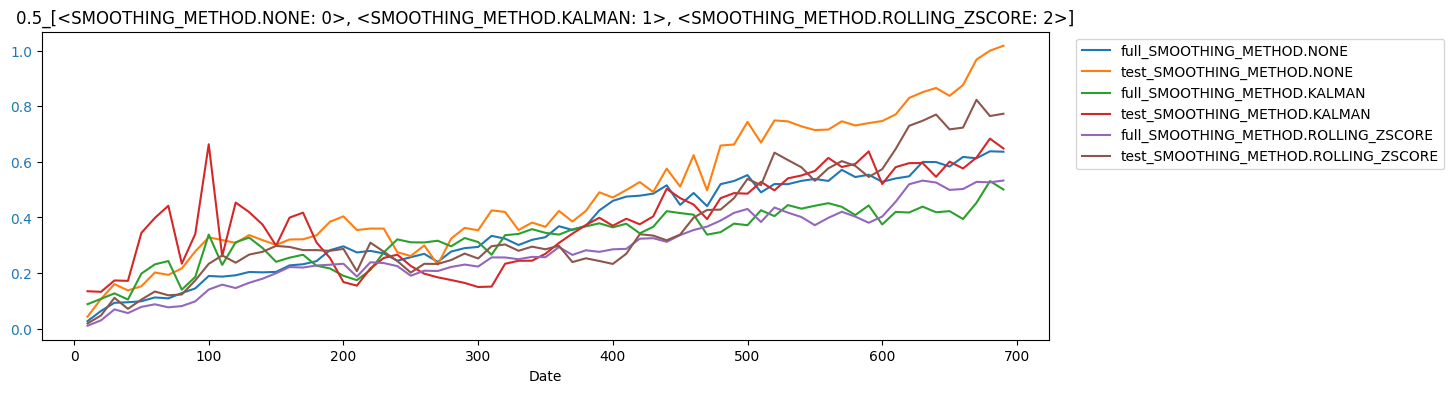

,full_SMOOTHING_METHOD.NONE,test_SMOOTHING_METHOD.NONE,full_SMOOTHING_METHOD.KALMAN,test_SMOOTHING_METHOD.KALMAN,full_SMOOTHING_METHOD.ROLLING_ZSCORE,test_SMOOTHING_METHOD.ROLLING_ZSCORE
10,0.026730,0.042869,0.087908,0.134342,0.010341,0.018673
20,0.063405,0.106416,0.107028,0.132277,0.029697,0.047213
30,0.092900,0.160022,0.126745,0.173212,0.069009,0.110736
40,0.094785,0.137404,0.104610,0.171694,0.055851,0.071058
50,0.098388,0.152458,0.197961,0.344395,0.078146,0.104386
...,...,...,...,...,...,...
650,0.583085,0.837553,0.422682,0.600700,0.499060,0.716846
660,0.617630,0.876259,0.394188,0.576132,0.502214,0.723169
670,0.612789,0.967925,0.452757,0.615163,0.527892,0.823110
680,0.637948,0.999835,0.530786,0.683523,0.526375,0.764803


In [9]:
c.compare_pnl(0.5)

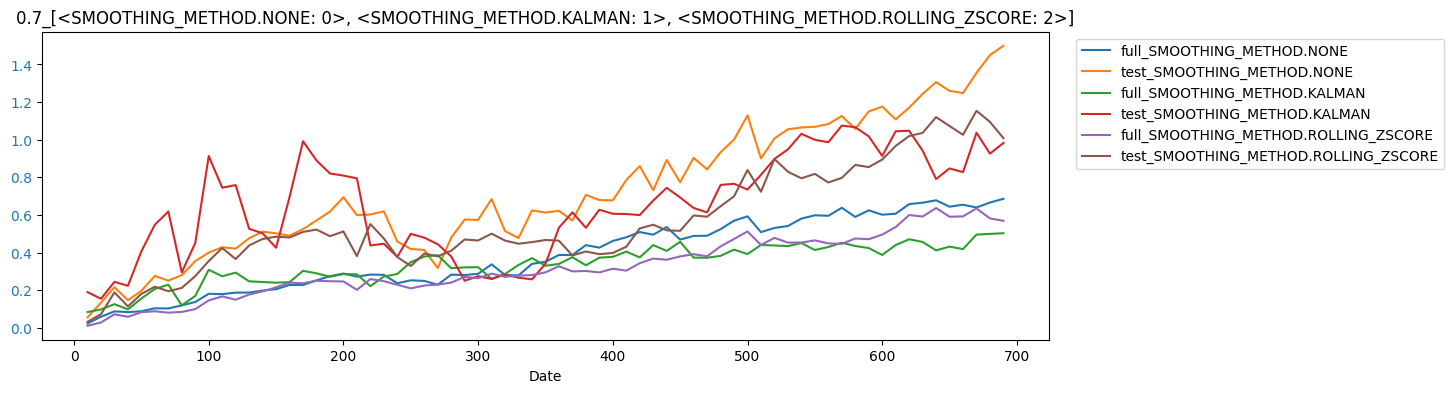

,full_SMOOTHING_METHOD.NONE,test_SMOOTHING_METHOD.NONE,full_SMOOTHING_METHOD.KALMAN,test_SMOOTHING_METHOD.KALMAN,full_SMOOTHING_METHOD.ROLLING_ZSCORE,test_SMOOTHING_METHOD.ROLLING_ZSCORE
10,0.023429,0.054936,0.083401,0.189482,0.010884,0.031956
20,0.058546,0.133573,0.097728,0.154223,0.027931,0.072099
30,0.087192,0.215751,0.125559,0.244203,0.071725,0.188253
40,0.083238,0.146511,0.097744,0.223050,0.058143,0.113456
50,0.087796,0.196832,0.155723,0.406536,0.083040,0.180263
...,...,...,...,...,...,...
650,0.643854,1.259439,0.431325,0.847262,0.590375,1.072641
660,0.654333,1.248141,0.418512,0.827507,0.592205,1.025975
670,0.639414,1.355190,0.495174,1.036916,0.634451,1.153530
680,0.665961,1.449465,0.499114,0.925758,0.581466,1.094374


In [10]:
c.compare_pnl(0.7)

In [11]:
method = SMOOTHING_METHOD.KALMAN
xx = c.get_pnl_all(400, train_ratio=0.7, method=method, test_only=False)
print(xx.groupby(['ccy'])['return'].sum().sort_values(ascending=True).to_string())

ccy
GBPXAU   -0.305917
EURXAU   -0.158226
JPYUSD   -0.070036
JPYGBP   -0.065695
JPYXAU   -0.046448
CHFXAU   -0.038974
AUDGBP   -0.027558
USDXAU   -0.016857
CHFEUR   -0.012184
AUDUSD   -0.001551
USDEUR   -0.001402
JPYCHF    0.017769
AUDCAD    0.023668
USDCAD    0.074230
EURXAG    0.075557
CADXAG    0.093077
USDGBP    0.114420
GBPCHF    0.188212
GBPXAG    0.199890
CHFXAG    0.223384
GBPEUR    0.231222
CADCHF    0.234380
USDXAG    0.256213
JPYEUR    0.258795
JPYCAD    0.259591
GBPCAD    0.262372
CADEUR    0.277668
AUDJPY    0.287907
AUDCHF    0.296551
AUDEUR    0.311352
USDCHF    0.382861
AUDXAG    0.396441
CADXAU    0.416969
XAUXAG    0.493826
AUDXAU    0.697685
AUDOIL    0.732997
JPYXAG    0.787428
CHFOIL    0.837414
GBPOIL    0.856505
USDOIL    0.872919
XAGOIL    0.974637
EUROIL    0.997884
JPYOIL    1.183102
XAUOIL    1.468904
CADOIL    1.950993
EURGAS    2.525675
CHFGAS    2.826887
GBPGAS    3.484561
USDGAS    4.253952
XAUGAS    4.297363
XAGGAS    4.449500
CADGAS    4.832941
AUDGAS  

In [12]:
xx = c.get_pnl_all(400, train_ratio=0.7, method=SMOOTHING_METHOD.KALMAN, test_only=False)
print(xx.groupby(['ccy'])['return'].sum().sort_values(ascending=True).to_string())
# xx.groupby(['year'])['return'].sum()

ccy
GBPXAU   -0.305917
EURXAU   -0.158226
JPYUSD   -0.070036
JPYGBP   -0.065695
JPYXAU   -0.046448
CHFXAU   -0.038974
AUDGBP   -0.027558
USDXAU   -0.016857
CHFEUR   -0.012184
AUDUSD   -0.001551
USDEUR   -0.001402
JPYCHF    0.017769
AUDCAD    0.023668
USDCAD    0.074230
EURXAG    0.075557
CADXAG    0.093077
USDGBP    0.114420
GBPCHF    0.188212
GBPXAG    0.199890
CHFXAG    0.223384
GBPEUR    0.231222
CADCHF    0.234380
USDXAG    0.256213
JPYEUR    0.258795
JPYCAD    0.259591
GBPCAD    0.262372
CADEUR    0.277668
AUDJPY    0.287907
AUDCHF    0.296551
AUDEUR    0.311352
USDCHF    0.382861
AUDXAG    0.396441
CADXAU    0.416969
XAUXAG    0.493826
AUDXAU    0.697685
AUDOIL    0.732997
JPYXAG    0.787428
CHFOIL    0.837414
GBPOIL    0.856505
USDOIL    0.872919
XAGOIL    0.974637
EUROIL    0.997884
JPYOIL    1.183102
XAUOIL    1.468904
CADOIL    1.950993
EURGAS    2.525675
CHFGAS    2.826887
GBPGAS    3.484561
USDGAS    4.253952
XAUGAS    4.297363
XAGGAS    4.449500
CADGAS    4.832941
AUDGAS  

In [13]:
xx = c.get_pnl_all(400, train_ratio=0.7, test_only=True)

In [14]:
xx

,year,ccy,entry_idx,exit_idx,entry_price,exit_price,spread,ccy1_rank,ccy2_rank,method,return
0,2019,AUDJPY,2019-06-17,2020-12-29,74.472160,78.898050,-1.407031,2,10,SMOOTHING_METHOD.ROLLING_ZSCORE,0.059430
1,2019,AUDUSD,2019-09-18,2020-08-18,0.684400,0.723500,-1.482336,2,8,SMOOTHING_METHOD.ROLLING_ZSCORE,0.057130
2,2018,AUDGBP,2018-10-05,2020-09-10,0.537974,0.567258,-1.020295,2,8,SMOOTHING_METHOD.ROLLING_ZSCORE,0.054434
3,2018,AUDCAD,2018-10-03,2020-06-03,0.915520,0.937216,-0.717812,2,7,SMOOTHING_METHOD.ROLLING_ZSCORE,0.023698
4,2019,AUDCHF,2019-08-14,2020-12-31,0.656401,0.681553,-1.245357,2,8,SMOOTHING_METHOD.ROLLING_ZSCORE,0.038317
...,...,...,...,...,...,...,...,...,...,...,...
108,2020,OILGAS,2020-03-13,2020-06-09,16.350515,23.202381,-3.609380,1,2,SMOOTHING_METHOD.ROLLING_ZSCORE,0.419061
109,2021,OILGAS,2021-02-11,2021-03-08,8.956923,24.355805,-4.324568,2,11,SMOOTHING_METHOD.ROLLING_ZSCORE,1.719216
110,2021,OILGAS,2021-12-09,2022-01-10,19.310627,18.776442,5.583486,11,10,SMOOTHING_METHOD.ROLLING_ZSCORE,0.027663
111,2022,OILGAS,2022-10-12,2022-10-14,13.307576,14.114754,4.894578,11,1,SMOOTHING_METHOD.ROLLING_ZSCORE,-0.060656


(np.float64(-0.2768264796259509), np.float64(0.39343887693915996))


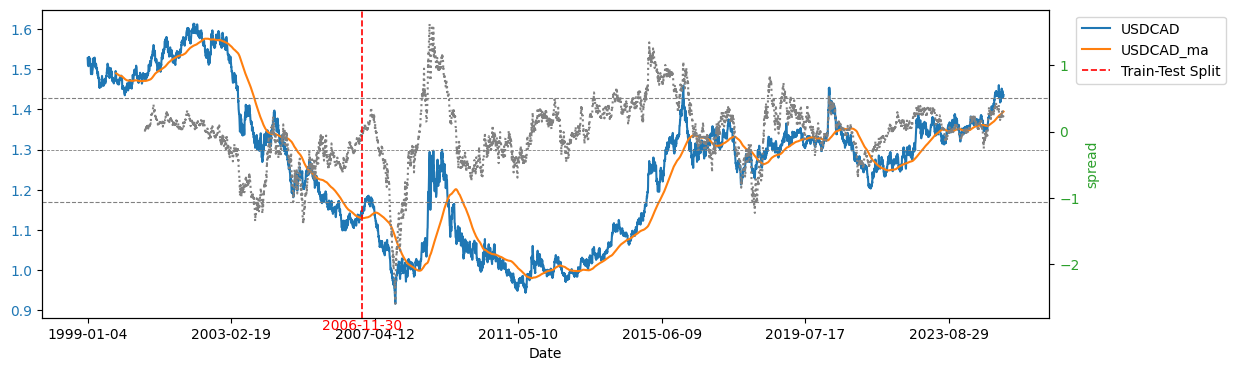

(np.float64(-0.2285180311315758), np.float64(0.5355851728939421))


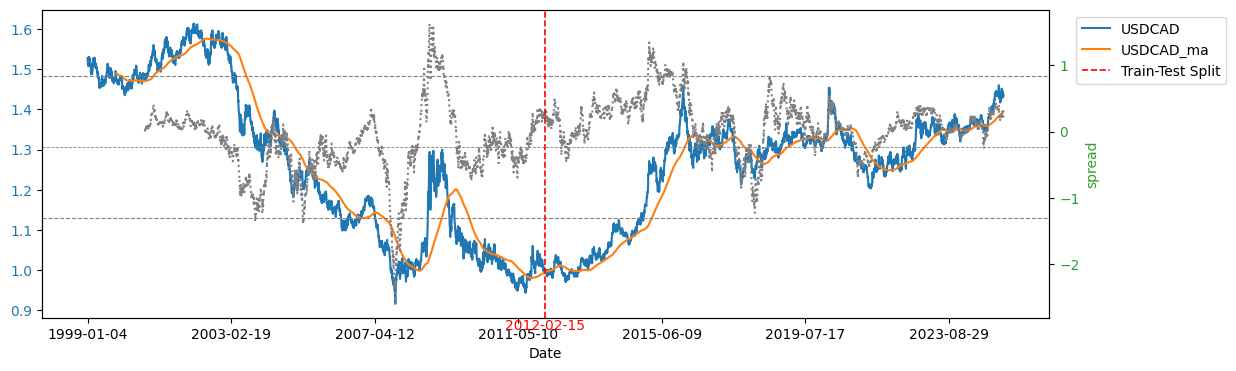

(np.float64(-0.05916939830724599), np.float64(0.5504849809695849))


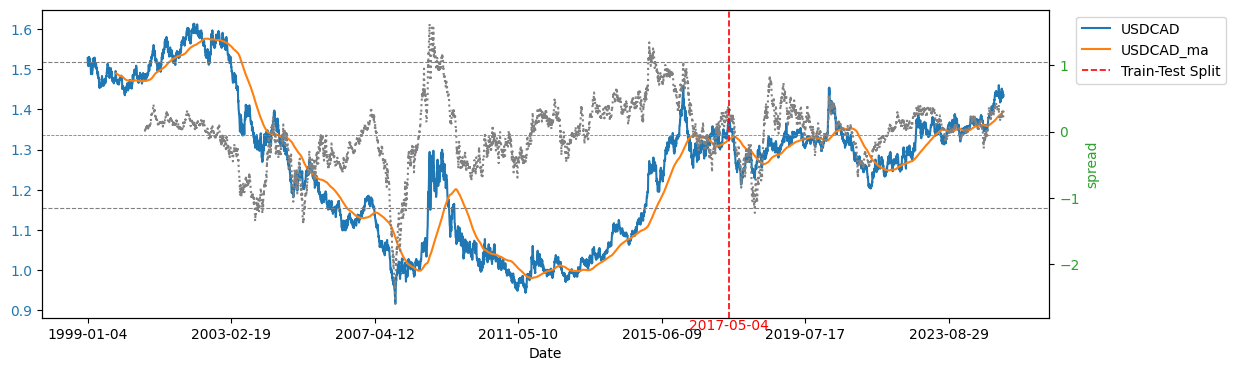

(np.float64(-0.03130275388819778), np.float64(0.48966926043163866))


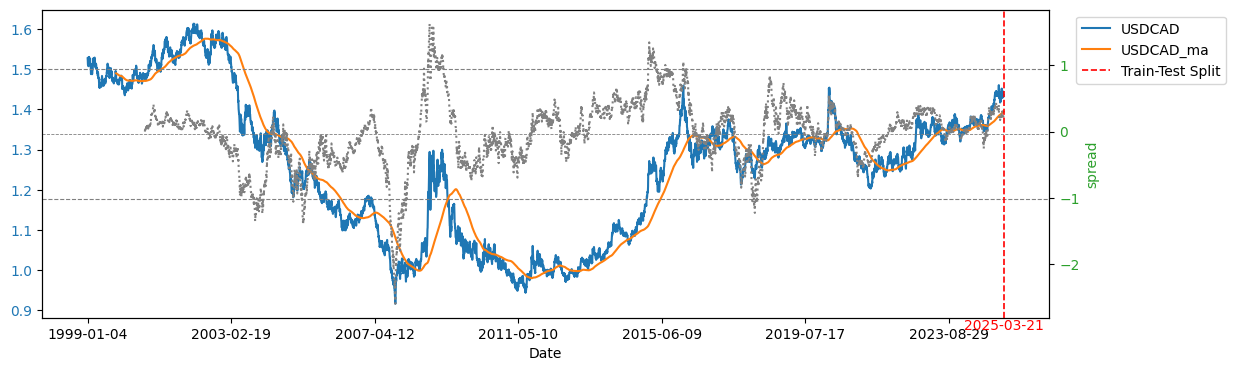

In [15]:
dt = '1991-01-01'
pair ='USDCAD'
window = 200
spread = c.get_spread(pair, window, train_ratio=0.3, visualize=True)
spread = c.get_spread(pair, window, train_ratio=0.5, visualize=True)
spread = c.get_spread(pair, window, train_ratio=0.7, visualize=True)
spread = c.get_spread(pair, window, train_ratio=1.0, visualize=True)

In [16]:
c

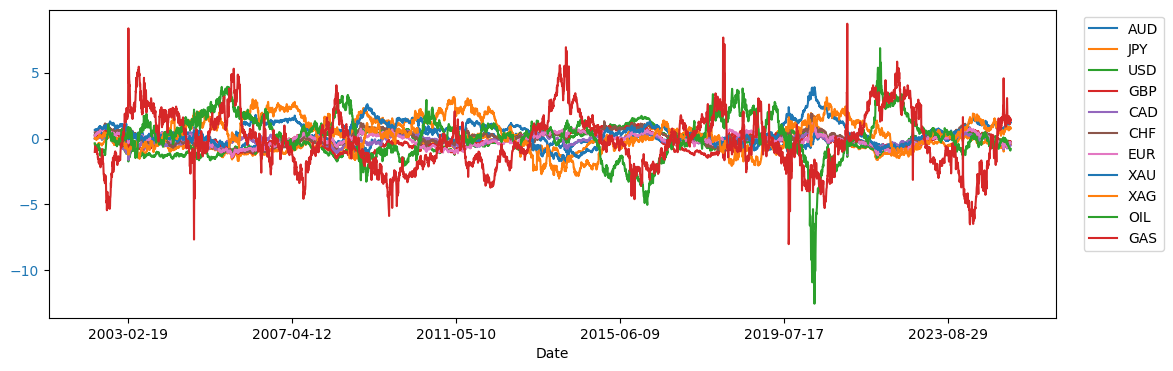

In [17]:
HELPER.plot_chart(c.rolling_cross_csi_zscore(window=400))

year                                      2002
ccy                                     USDCAD
entry_idx                           2002-04-24
exit_idx                            2002-05-07
entry_price                             1.5685
exit_price                              1.5705
spread                               -2.907698
ccy1_rank                                    1
ccy2_rank                                    5
method         SMOOTHING_METHOD.ROLLING_ZSCORE
return                                0.001275
Name: 1228, dtype: object


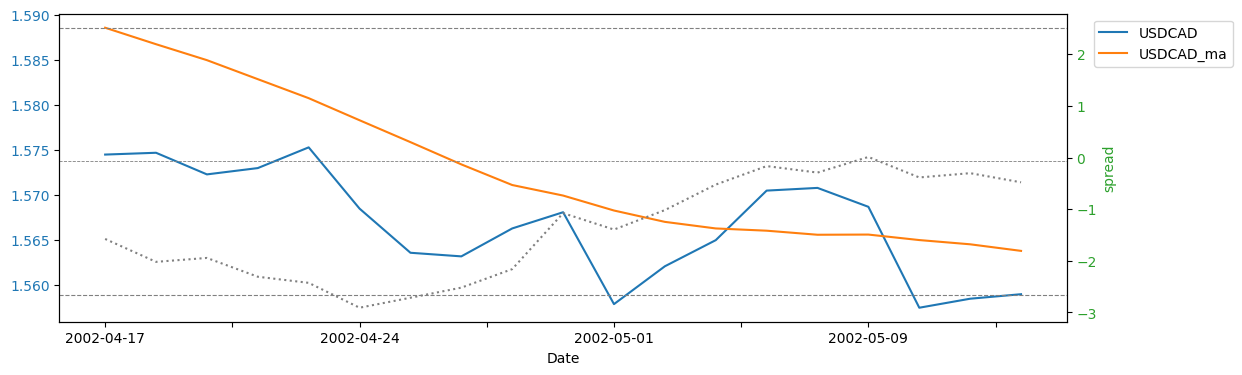

0.0022907251169715253


In [18]:
c2 = CCY_STR_DEBUG(pair, 10)

df= c2.debug_pair_v2(idx=1, extra_window=5)

print(df['return'].mean())

year                                      2007
ccy                                     USDCAD
entry_idx                           2007-11-02
exit_idx                            2008-08-08
entry_price                              0.936
exit_price                              1.0677
spread                               -3.432942
ccy1_rank                                    1
ccy2_rank                                    6
method         SMOOTHING_METHOD.ROLLING_ZSCORE
return                                0.140705
Name: 70, dtype: object


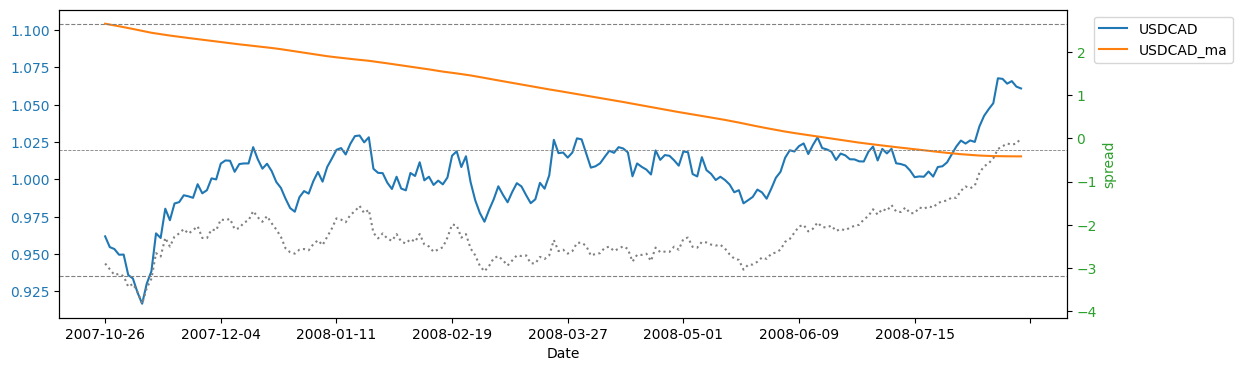

0.0647948750065706


In [19]:
c2 = CCY_STR_DEBUG(pair, 300)

df= c2.debug_pair_v2(idx=1, extra_window=5)

print(df['return'].mean())

In [20]:
df

,year,ccy,entry_idx,exit_idx,entry_price,exit_price,spread,ccy1_rank,ccy2_rank,method,return
69,2005,USDCAD,2005-08-01,2006-12-15,1.2136,1.1574,-3.336631,2,7,SMOOTHING_METHOD.ROLLING_ZSCORE,-0.046309
70,2007,USDCAD,2007-11-02,2008-08-08,0.9360,1.0677,-3.432942,1,6,SMOOTHING_METHOD.ROLLING_ZSCORE,0.140705
71,2008,USDCAD,2008-10-24,2009-11-25,1.2735,1.0499,2.801646,5,3,SMOOTHING_METHOD.ROLLING_ZSCORE,0.175579
72,2015,USDCAD,2015-07-23,2016-12-12,1.3030,1.3137,2.771042,7,4,SMOOTHING_METHOD.ROLLING_ZSCORE,-0.008212
73,2021,USDCAD,2021-06-04,2022-02-24,1.2088,1.2840,-3.249874,2,6,SMOOTHING_METHOD.ROLLING_ZSCORE,0.062210


In [21]:

method = SMOOTHING_METHOD.KALMAN
df = c.get_pnl_all(400, method=method)
yy = df.groupby(['year', 'method'])['return'].count()
xx = df.groupby(['year', 'method'])['return'].sum()
yy2 = yy.xs(key=method, level=1).sort_index()
xx2 =xx.xs(key=method, level=1).sort_index()

out = pd.concat([yy2, xx2], axis=1)
print(out)
print(out.sum().sum())

      return     return
year                   
2000      11  15.191381
2001       1   0.075752
2002       8   3.011037
2003       6   0.931640
2004       1   0.082164
2006       6   0.114497
2007       1   0.132696
2008      11   2.512617
2009      15   3.604106
2010      12   0.039223
2011      10   2.043141
2012       2   0.797132
2013      12   1.179593
2014      11   4.426663
2015      11   1.244973
2016       3   0.666816
2017       1   0.099715
2020      13   8.832675
2021      18  11.982488
2022       2   3.356891
2023       6   1.343342
2024       4   0.547336
227.21587746335643


In [22]:
method = SMOOTHING_METHOD.KALMAN
df = c.get_pnl_all(200, method=method)
yy = df.groupby(['year', 'method'])['return'].count()
xx = df.groupby(['year', 'method'])['return'].sum()
yy2 = yy.xs(key=method, level=1).sort_index()
xx2 =xx.xs(key=method, level=1).sort_index()

out = pd.concat([yy2, xx2], axis=1)
print(out)
print(out.sum().sum())

      return     return
year                   
1999       8  -0.819825
2000      15   7.062724
2001      10   4.582847
2003       4  -0.097358
2004       5   1.068669
2005       2  -0.126583
2006      25   4.057935
2007       1   0.042386
2008      32   6.549021
2009      23   3.656927
2010      13  -0.054672
2011       5   0.751720
2012       8   0.952414
2013      20  -0.262065
2014       2   0.096404
2015      13   0.809077
2016       7   0.624882
2017       1   0.033411
2020      12   6.157168
2021      24  29.817079
2022       3   3.285727
2023      10   1.161793
312.3496811851435


In [23]:
df = c.get_pnl_all(400)
yy = df.groupby(['ccy', 'method'])['return'].count()
xx = df.groupby(['ccy', 'method'])['return'].sum()
yy2 = yy.xs(key=SMOOTHING_METHOD.ROLLING_ZSCORE, level=1).sort_index()
yy2.name = 'count'
xx2 =xx.xs(key=SMOOTHING_METHOD.ROLLING_ZSCORE, level=1).sort_index()

print(pd.concat([yy2, xx2], axis=1).sort_values('return'))

        count     return
ccy                     
CHFXAU      3  -0.093113
JPYGBP      2  -0.079543
USDEUR      3  -0.054038
USDXAU      2  -0.053772
JPYXAU      4  -0.052864
JPYUSD      2  -0.036069
AUDGBP      3  -0.010168
JPYEUR      2   0.016111
JPYCHF      4   0.047469
CHFXAG      2   0.048547
CHFEUR      5   0.076242
CADXAG      2   0.092037
GBPXAU      3   0.099727
USDGBP      3   0.110966
AUDCAD      4   0.134152
GBPEUR      3   0.143943
GBPCHF      3   0.151430
CADXAU      3   0.154731
USDCAD      3   0.191502
JPYCAD      3   0.212010
AUDJPY      3   0.234360
USDXAG      2   0.260704
AUDEUR      5   0.262462
USDCHF      4   0.287059
EURXAU      3   0.305999
CADEUR      5   0.320963
GBPCAD      6   0.393293
AUDCHF      6   0.420542
CADCHF      5   0.424034
GBPXAG      3   0.432080
AUDXAU      4   0.441423
EURXAG      3   0.560133
AUDUSD      4   0.700114
AUDXAG      4   0.720682
CHFOIL      6   0.756127
XAUXAG      6   0.800542
AUDOIL      7   0.936128
EUROIL      7   0.968846
